In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/nppe-dlp-2026-term-1/sample_submission.csv
/kaggle/input/competitions/nppe-dlp-2026-term-1/train.csv
/kaggle/input/competitions/nppe-dlp-2026-term-1/test.csv


In [2]:
!pip install -q peft
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.8 MB/s eta 0:00:00


In [3]:
import transformers
import torch
import peft
import bitsandbytes as bnb

print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("peft:", peft.__version__)
print("bitsandbytes:",bnb.__version__)

transformers: 5.2.0
torch: 2.9.0+cu126
peft: 0.18.1
bitsandbytes: 0.49.2


In [4]:
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla P100-PCIE-16GB


In [5]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
hf_token = user_secrets.get_secret("HF_TOKEN")

login(token=hf_token)

In [6]:

TRAIN_PATH = "/kaggle/input/competitions/nppe-dlp-2026-term-1/train.csv"
TEST_PATH = "/kaggle/input/competitions/nppe-dlp-2026-term-1/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (900, 4)
Test shape: (100, 3)


In [7]:
train_df.head()

,ID,sentence,label,language
0,82,ਇਹ ਫਿਲਮ ਇੱਕ ਬੇਹਤਰੀਨ ਕਹਾਣੀ ਸੁਣਾਉਣ ਦਾ ਸਭ ਤੋਂ ਵਧੀ...,Negative,pa
1,618,"ਇੱਕ ਸਮਗਰੀ ਦੇ ਰੂਪ ਵਿੱਚ, ਕੋਟਿੰਗ ਤੋਂ ਬਿਨਾਂ, ਸਿਰਫ ...",Negative,pa
2,812,"ബ്രിസിലുകൾ കട്ടിയുള്ള പ്ലാസ്റ്റിക് ആണ്, അതിനാൽ...",Negative,ml
3,304,এটি বিআইএস প্রত্যয়িত এবং নিরাপদ বলে দাবি করা হয়।,Positive,bn
4,295,6 mAh બેટરી અને લાંબા સમય સુધી ચાલતી નથી.,Negative,gu


In [8]:
test_df.head()

,ID,sentence,language
0,550,നന്നായി പരിപാലിക്കപ്പെടുന്നതും വൃത്തിയുള്ളതുമാ...,ml
1,397,ക്യാമറ ലെൻസിൽ നന്നായി ചേരുന്നതിനാൽ പൊടിയിൽ നിന...,ml
2,757,ਕੂਲਰ ਵਧੀਆ ਕੈਸਟਰ ਦੇ ਪਹੀਏ ਨਾਲ ਫਿੱਟ ਹੁੰਦਾ ਹੈ। ਹਾਲ...,pa
3,407,"రాకెట్ తేలికగా ఉన్నప్పటికీ, యోనెక్స్ రాకెట్లతో...",te
4,294,गासै रोखोमनि दामनाय आदब स्मार्टफनफोरजोंबो गोरो...,bd


In [9]:
train_df["label"].value_counts()

label
Positive    456
Negative    444
Name: count, dtype: int64

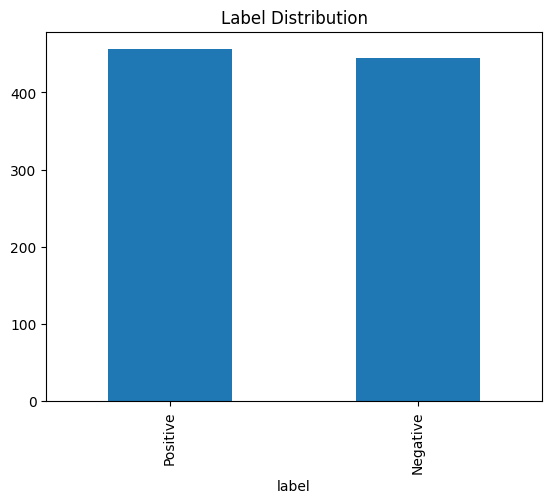

In [10]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.show()

In [11]:
train_df["language"].value_counts()

language
ta    76
hi    74
or    72
pa    72
as    71
bd    71
gu    69
ml    68
mr    67
kn    66
ur    66
bn    65
te    63
Name: count, dtype: int64

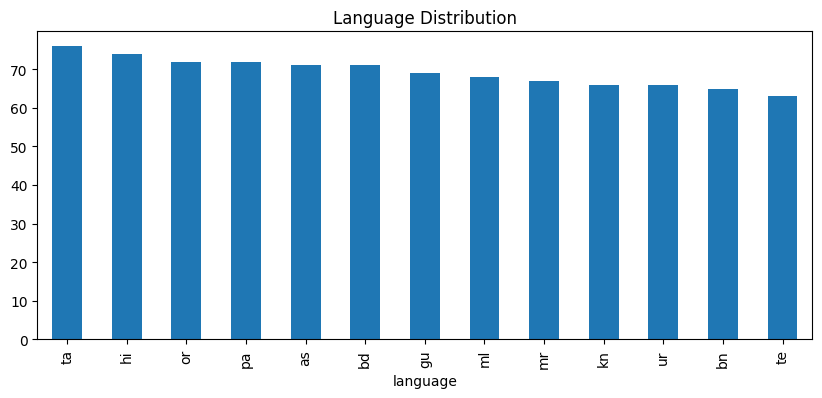

In [12]:
train_df["language"].value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Language Distribution")
plt.show()

In [13]:
train_df["length"] = train_df["sentence"].apply(len)

train_df["length"].describe()

count    900.000000
mean     136.631111
std       73.122747
min       14.000000
25%       85.000000
50%      126.000000
75%      169.000000
max      527.000000
Name: length, dtype: float64

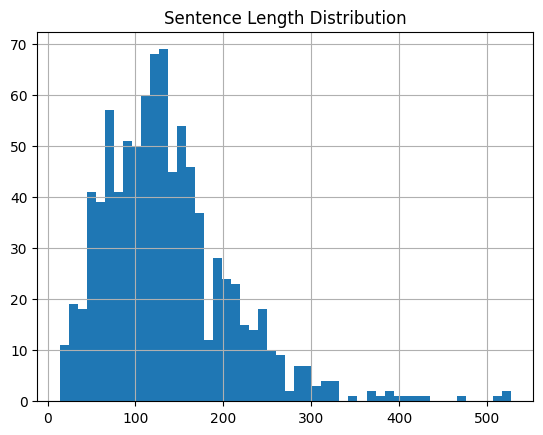

In [14]:
train_df["length"].hist(bins=50)
plt.title("Sentence Length Distribution")
plt.show()

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-1b-it")

train_df["token_length"] = train_df["sentence"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [16]:
train_df["token_length"].describe()

count    900.000000
mean      51.442222
std       30.344445
min        4.000000
25%       30.000000
50%       45.500000
75%       66.000000
max      195.000000
Name: token_length, dtype: float64

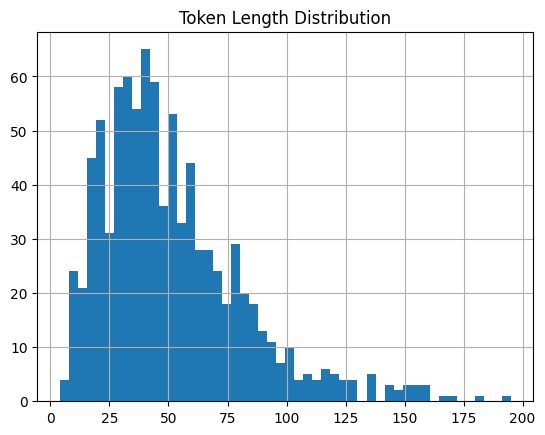

In [17]:
train_df["token_length"].hist(bins=50)
plt.title("Token Length Distribution")
plt.show()

In [18]:
train_df["sentence"].duplicated().sum()

np.int64(0)

In [19]:
pd.crosstab(train_df["language"], train_df["label"])

label,Negative,Positive
language,,
as,35,36
bd,35,36
bn,31,34
gu,34,35
hi,35,39
kn,33,33
ml,33,35
mr,36,31
or,35,37


In [20]:
for lang in train_df["language"].unique():
    
    sample = train_df[train_df["language"] == lang]["sentence"].iloc[0]
    
    print(lang, ":", sample)

pa : ਇਹ ਫਿਲਮ ਇੱਕ ਬੇਹਤਰੀਨ ਕਹਾਣੀ ਸੁਣਾਉਣ ਦਾ ਸਭ ਤੋਂ ਵਧੀਆ ਉਦਾਹਰਣ ਹੈ, ਪਰ ਇਹ ਸਭ ਨਕਾਰਾਤਮਕ ਅਰਥਾਂ ਵਿੱਚ ਕੀਤਾ ਗਿਆ ਹੈ। ਤੁਹਾਨੂੰ ਹਰ ਦ੍ਰਿਸ਼ ਨੂੰ ਸਮਝਣ ਲਈ ਸਮਾਂ ਕੱਢਣਾ ਹੋਵੇਗਾ!
ml : ബ്രിസിലുകൾ കട്ടിയുള്ള പ്ലാസ്റ്റിക് ആണ്, അതിനാൽ അവ രോമത്തിൽ തുളച്ചുകയറുന്നില്ല.
bn : এটি বিআইএস প্রত্যয়িত এবং নিরাপদ বলে দাবি করা হয়।
gu : 6 mAh બેટરી અને લાંબા સમય સુધી ચાલતી નથી.
as : যদিও কুলাৰটোত এখন ডাঙৰ ফেন আছে, ইয়াত ব্ল'ৱাৰ নাই। গতিকে যদিও শীতল কৰাৰ ক্ষমতা ভাল, বতাহ বিয়পি পৰে আৰু অদক্ষ যেন লাগে।
ur : اس پروڈکٹ کا خوشبو سے پاک معیار بہترین ہے، خاص طور پر سونگھنے کی شدید حس رکھنے والی نئی ماؤں کے لیے۔ اس کی بڑے پیمانے پر سفارش کریں۔
mr : मी या चित्रपटाची शिफारस करणार नाही कारण यात कोणतीही असाधारण गोष्ट नाही. व्हिज्युअल गंमत शून्य आहे, काही दृश्ये नाहीत, अतिशय सामान्य पार्श्वभूमी आहे.
ta : பெரும்பாலான இடங்களில் மங்கலான விளக்குகள் இருக்கின்றன மற்றும் பாதைகள் உடைந்திருக்கின்றன. பராமரிப்பு தேவை!
hi : ह्यूमर से भरपूर फिल्म और जबरदस्त सिंगल लाइनर्स! एकमात्र रोलर कोस्टर जो आपको पूरी  फिल्म  के दौरान हंसाता रहेगा।
te : దయచేసి పుస

In [21]:
def build_prompt(sentence, language):
    
    return f"""You are a multilingual sentiment classifier.

Task:
Determine whether the sentiment of the following sentence is Positive or Negative.

Rules:
Respond with exactly one word:
Positive or Negative.

Sentence language: {language}

Sentence:
{sentence}

Answer:
"""

In [22]:
train_df["prompt"] = train_df.apply(
    lambda x: build_prompt(x["sentence"], x["language"]),
    axis=1
)

In [23]:
print(train_df["prompt"].iloc[0])

You are a multilingual sentiment classifier.

Task:
Determine whether the sentiment of the following sentence is Positive or Negative.

Rules:
Respond with exactly one word:
Positive or Negative.

Sentence language: pa

Sentence:
ਇਹ ਫਿਲਮ ਇੱਕ ਬੇਹਤਰੀਨ ਕਹਾਣੀ ਸੁਣਾਉਣ ਦਾ ਸਭ ਤੋਂ ਵਧੀਆ ਉਦਾਹਰਣ ਹੈ, ਪਰ ਇਹ ਸਭ ਨਕਾਰਾਤਮਕ ਅਰਥਾਂ ਵਿੱਚ ਕੀਤਾ ਗਿਆ ਹੈ। ਤੁਹਾਨੂੰ ਹਰ ਦ੍ਰਿਸ਼ ਨੂੰ ਸਮਝਣ ਲਈ ਸਮਾਂ ਕੱਢਣਾ ਹੋਵੇਗਾ!

Answer:



In [24]:
from sklearn.model_selection import train_test_split

train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

print("Train size:", len(train_df_split))
print("Validation size:", len(val_df))

Train size: 720
Validation size: 180


In [25]:
def build_training_text(row):

    prompt = build_prompt(row["sentence"], row["language"])
    
    return prompt + row["label"]

In [26]:
train_df_split["text"] = train_df_split.apply(build_training_text, axis=1)
val_df["text"] = val_df.apply(build_training_text, axis=1)

In [27]:
print(train_df_split["text"].iloc[325])

You are a multilingual sentiment classifier.

Task:
Determine whether the sentiment of the following sentence is Positive or Negative.

Rules:
Respond with exactly one word:
Positive or Negative.

Sentence language: hi

Sentence:
यह ट्रायन आईटी पार्क (पहले इनोर्बिट मॉल) के अंदर टॉप सर्विसेज़ के साथ एक बेहतरीन सिनेमा मल्टीप्लेक्स हॉल है।

Answer:
Positive


In [28]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df_split[["text"]])
val_dataset = Dataset.from_pandas(val_df[["text"]])

train_dataset

Dataset({
    features: ['text', '__index_level_0__'],
    num_rows: 720
})

In [29]:
val_dataset

Dataset({
    features: ['text', '__index_level_0__'],
    num_rows: 180
})

In [30]:

model_name = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer.pad_token = tokenizer.eos_token

In [31]:
def tokenize(example):

    text = example["text"]

    tokens = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128
    )

    labels = tokens["input_ids"].copy()

    answer_token_ids = tokenizer("Answer:")["input_ids"]

    start = None

    for i in range(len(labels) - len(answer_token_ids)):
        if labels[i:i+len(answer_token_ids)] == answer_token_ids:
            start = i + len(answer_token_ids)
            break

    if start is not None:
        for j in range(start):
            labels[j] = -100

    tokens["labels"] = labels

    return tokens

In [32]:
train_dataset = train_dataset.map(tokenize)
val_dataset = val_dataset.map(tokenize)

train_dataset

Map:   0%|          | 0/720 [00:00<?, ? examples/s]

Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Dataset({
    features: ['text', '__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 720
})

In [33]:
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

train_dataset

Dataset({
    features: ['__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 720
})

In [34]:
val_dataset

Dataset({
    features: ['__index_level_0__', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 180
})

In [35]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig


In [36]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

In [37]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16
)

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

In [38]:
from peft import prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

In [39]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    # target_modules=["q_proj","k_proj","v_proj","o_proj"],
    target_modules=["q_proj","v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [40]:
model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 1,490,944 || all params: 1,001,376,896 || trainable%: 0.1489


In [41]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    
    output_dir="/kaggle/working/gemma_lora_v7",
    
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    
    gradient_accumulation_steps=4,
    
    num_train_epochs=5,
    
    learning_rate=2e-4,
    
    logging_steps=10,
    
    eval_strategy="epoch",
    save_strategy="epoch",
    
    fp16=True,
    
    report_to="none"
)


In [42]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [43]:
len(train_dataset), len(val_dataset)

(720, 180)

In [44]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,5.171864,5.092185
2,4.989476,4.970929
3,4.918724,4.926798
4,4.903204,4.901484
5,4.954342,4.892415


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

TrainOutput(global_step=225, training_loss=5.069985936482747, metrics={'train_runtime': 577.9157, 'train_samples_per_second': 6.229, 'train_steps_per_second': 0.389, 'total_flos': 1933665199718400.0, 'train_loss': 5.069985936482747, 'epoch': 5.0})

In [45]:
trainer.model.save_pretrained("/kaggle/working/gemma_lora_v7")

In [46]:
def predict_sentiment(prompt):

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2,
            do_sample=False,
            temperature=0
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return text

In [47]:
def extract_label(text):

    text = text.lower()

    if "answer:" in text:
        text = text.split("answer:")[-1]

    if "negative" in text:
        return "Negative"

    if "positive" in text:
        return "Positive"

    return "Negative"

In [48]:
from sklearn.metrics import f1_score

predictions = []
true_labels = []

for _, row in val_df.iterrows():

    prompt = build_prompt(row["sentence"], row["language"])

    output = predict_sentiment(prompt)

    pred = extract_label(output)

    predictions.append(pred)
    true_labels.append(row["label"])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [49]:
val_results = val_df.copy()

val_results["prediction"] = predictions
val_results["correct"] = val_results["prediction"] == val_results["label"]

val_results.head()

,ID,sentence,label,language,length,token_length,prompt,text,prediction,correct
698,716,"ಮಂಗಳ ಗ್ರಹಕ್ಕಿಂತ ಹೆಚ್ಚಾಗಿ, ಮರುಭೂಮಿಯಂತೆ ಕಾಣುತ್ತಿ...",Negative,kn,88,34,You are a multilingual sentiment classifier.\n...,You are a multilingual sentiment classifier.\n...,Negative,True
317,546,പിൻവശത്തെ പേജിൽ നിന്നുള്ള ചിത്രങ്ങൾ/വരികൾ ദൃശ്...,Negative,ml,239,80,You are a multilingual sentiment classifier.\n...,You are a multilingual sentiment classifier.\n...,Negative,True
509,425,Audible आ साउन्दनि गुनखौ बांहोनायनि गोनांथि दं...,Negative,bd,119,60,You are a multilingual sentiment classifier.\n...,You are a multilingual sentiment classifier.\n...,Negative,True
170,301,ਫ਼ਿਲਮ ਦੇ ਦੌਰਾਨ ਬੱਨੀ ਦੇ ਜੋਸ਼ ਵਿੱਚ ਕਦੀ ਵੀ ਕਮੀ ਨਹੀ...,Positive,pa,98,45,You are a multilingual sentiment classifier.\n...,You are a multilingual sentiment classifier.\n...,Negative,False
638,221,"ভিডিঅ' কলিং ব্যৱহাৰ কৰিবলৈ, তেওঁলোকে আপোনাক তে...",Negative,as,177,76,You are a multilingual sentiment classifier.\n...,You are a multilingual sentiment classifier.\n...,Negative,True


In [50]:
language_errors = val_results.groupby("language")["correct"].apply(lambda x: (~x).sum())

language_errors.sort_values(ascending=False)

language
bd    10
or     6
pa     4
ur     3
as     2
te     1
mr     1
bn     1
kn     1
hi     0
gu     0
ml     0
ta     0
Name: correct, dtype: int64

In [51]:
language_stats = val_results.groupby("language").agg(
    total_samples=("correct", "count"),
    errors=("correct", lambda x: (~x).sum())
)

language_stats["error_rate"] = language_stats["errors"] / language_stats["total_samples"]

language_stats.sort_values("error_rate", ascending=False)

,total_samples,errors,error_rate
language,,,
bd,16,10,0.625000
or,14,6,0.428571
ur,13,3,0.230769
pa,19,4,0.210526
as,12,2,0.166667
bn,12,1,0.083333
mr,15,1,0.066667
te,15,1,0.066667
kn,17,1,0.058824


In [52]:
val_results[val_results["correct"] == False][["language","sentence","label","prediction"]]

,language,sentence,label,prediction
170,pa,ਫ਼ਿਲਮ ਦੇ ਦੌਰਾਨ ਬੱਨੀ ਦੇ ਜੋਸ਼ ਵਿੱਚ ਕਦੀ ਵੀ ਕਮੀ ਨਹੀ...,Positive,Negative
384,bd,अरिअ सेन्दउइस बिस्कुटाव क्रिम सोफाना होनाया जो...,Positive,Negative
892,kn,ನನ್ನ 5 ವರ್ಷದ ಮಗು ಆಕರ್ಷಕ ಕಥೆಗಳನ್ನು ಕೇಳುವುದನ್ನು ...,Positive,Negative
704,pa,ਮੈਂ ਬਹੁਤ ਲੰਬੇ ਸਮੇਂ ਤੋਂ ਲੈਕਮੇ ਉਤਪਾਦਾਂ ਦੀ ਵਰਤੋਂ ...,Positive,Negative
176,bd,हिन्जावफोरनि थाखाय दिहुननाय बेयो 48 घण्टासिम स...,Negative,Positive
305,bd,दोंफ्रोमबो सलʼवाव मोजां मोनलायनाय थाथारनांगौ ह...,Negative,Positive
310,ur,موسیقی حیرت انگیز، ورسٹائل اور نئی ہے! پریتم ن...,Positive,Negative
600,bd,एनद्रइदनि एपाव बिजाब गांसे नागिरनाया जोबोद बाथ...,Negative,Positive
587,bd,खामानि मावग्राफ्रा नोरोमै बाहायनाय आरो मोजां द...,Positive,Negative
510,bd,"""फोरमायथिनाया लुबैनाय जखानि नङा। लिरगिरि अम स्...",Negative,Positive


In [53]:
f1 = f1_score(true_labels, predictions, pos_label="Positive")

print("Validation F1:", f1)

Validation F1: 0.8361581920903954


In [54]:
for i in range(10):

    row = val_df.iloc[i]

    prompt = build_prompt(row["sentence"], row["language"])

    output = predict_sentiment(prompt)

    print("Sentence:", row["sentence"])
    print("True:", row["label"])
    print("Model output:", output)
    print()

Sentence: ಮಂಗಳ ಗ್ರಹಕ್ಕಿಂತ ಹೆಚ್ಚಾಗಿ, ಮರುಭೂಮಿಯಂತೆ ಕಾಣುತ್ತಿದೆ. . . . ವಿಶುವಲ್ ಎಫೆಕ್ಟ್‌ಗಳಲ್ಲಿ ಕಳಪೆ ಕೆಲಸ
True: Negative
Model output: You are a multilingual sentiment classifier.

Task:
Determine whether the sentiment of the following sentence is Positive or Negative.

Rules:
Respond with exactly one word:
Positive or Negative.

Sentence language: kn

Sentence:
ಮಂಗಳ ಗ್ರಹಕ್ಕಿಂತ ಹೆಚ್ಚಾಗಿ, ಮರುಭೂಮಿಯಂತೆ ಕಾಣುತ್ತಿದೆ. . . . ವಿಶುವಲ್ ಎಫೆಕ್ಟ್‌ಗಳಲ್ಲಿ ಕಳಪೆ ಕೆಲಸ

Answer:
Negative



Sentence: പിൻവശത്തെ പേജിൽ നിന്നുള്ള ചിത്രങ്ങൾ/വരികൾ ദൃശ്യമാകുന്നതിനാൽ ഞാൻ ഇത് ശുപാർശ ചെയ്യുന്നില്ല. ആകർഷകമായ ഡിസൈനുകളൊന്നുമില്ല, വാസ്തവത്തിൽ ഇതിൽ 4-5 വയസ് പ്രായമുള്ള കുട്ടികൾക്ക് അനുയോജ്യമല്ലാത്ത ഭയപ്പെടുത്തുന്ന പല്ലുകളും കണ്ണുകളുമുള്ള മൃഗങ്ങളുണ്ട്.
True: Negative
Model output: You are a multilingual sentiment classifier.

Task:
Determine whether the sentiment of the following sentence is Positive or Negative.

Rules:
Respond with exactly one word:
Positive or Negative.

Sentence language: ml

Sentence:
പിൻവശത്തെ പേജിൽ നിന്നുള

In [55]:
test_df["prompt"] = test_df.apply(
    lambda x: build_prompt(x["sentence"], x["language"]),
    axis=1
)

In [56]:
test_predictions = []

for _, row in test_df.iterrows():

    output = predict_sentiment(row["prompt"])

    label = extract_label(output)

    test_predictions.append(label)

In [57]:
numeric_predictions = [1 if p == "Positive" else 0 for p in test_predictions]

In [58]:
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "label": numeric_predictions
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

In [59]:
submission.head()

,ID,label
0,550,1
1,397,1
2,757,1
3,407,0
4,294,1
